# Welcome to SAOS: Solar Adaptive Optics Simulator

SAOS is a simulation platform developed in python that is designed for solar AO simulations. In this notebook, we will do a walkthrough to the main functionalities of SAOS.

## Telescope Class

First, we will build a telescope for our AO system. The telescope is defined by its pupil, the central obscuration and the spider. Additionally, the telescope holds the sampling time of the simulator, the resolution of the pupil and the maximum FoV.


** Note: all the modules of SAOS share a centralized logging stack. We need to create the logger that will be shared with all the modules.

2026-05-16 18:39:07,988 - INFO - Pupil dimensions: (200, 200)
2026-05-16 18:39:07,989 - INFO - Main properties: Sampling time [s] 0.0016666666666666668, Diameter [m] 1.5, Pixel size 0.0075, FoV 60


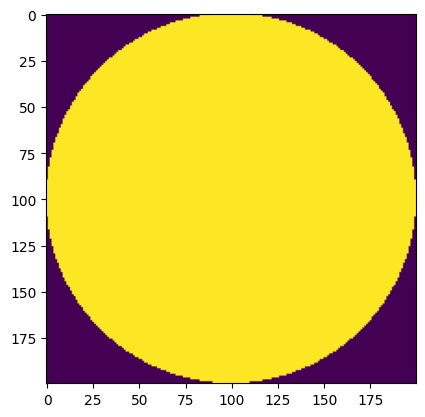

In [1]:
import numpy as np
import logging
from SAOS.LoggingHelper import LoggingHelper
import matplotlib.pyplot as plt
from SAOS.Telescope import Telescope

# Create the logger
example_logger = LoggingHelper(logging.INFO)
diameter = 1.5 # meters
samplingTime = 1/600. # in seconds
fov = 60 # in arcsec
resolution = 200 # number of pixels across the pupil diameter

tel = Telescope(diameter = diameter,
                resolution = resolution,
                centralObstruction= 0,
                samplingTime=samplingTime,
                fov=fov,
                logger=example_logger.logger)

example_logger.logger.info(f'Pupil dimensions: {tel.pupil.shape}')
example_logger.logger.info(f'Main properties: Sampling time [s] {tel.samplingTime}, Diameter [m] {tel.D}, Pixel size {tel.pixelSize}, FoV {tel.fov}')
plt.imshow(tel.pupil)



We can add a central obscuration, which is defined as a percentage of the telescope's diameter. 

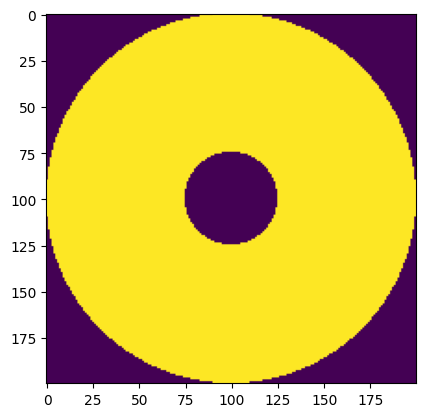

In [2]:
centralObscuration = 0.25 # % of the input diameter

tel = Telescope(diameter = diameter,
                resolution = resolution,
                centralObstruction= centralObscuration,
                samplingTime=samplingTime,
                fov=fov,
                logger=example_logger.logger)

plt.imshow(tel.pupil)

Also, we can add a spider to the telescope

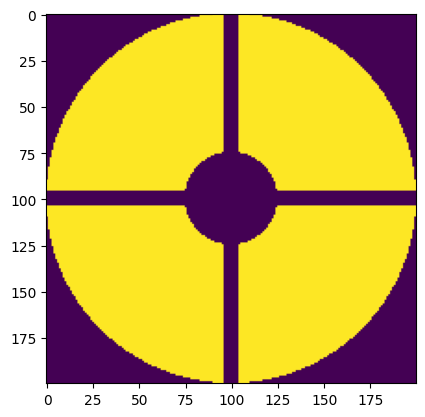

In [3]:
spider_width = 0.06 # in meters
spider_angle = [0, 90, 180, 270] # in [º]

tel.apply_spiders(spider_angle, spider_width)

plt.imshow(tel.pupil)

## Sources

There are two types of sources available: point source and sun. 

The point source is defined by its location on-sky, through the coordinates, given in polar [radius, angle] = [arcsec, degree]. Then, the magnitud of the star and the wavelength. Multiple wavelengths are supported, as shown below.

The number of photons of the source is used in the simulations where noise is included, if not, the energy is normalized to 1.

In [4]:
from SAOS.Source import Source

ngs = Source(magnitude = 12,
             optBand = 'V0',
             coordinates=[0,0],
             logger=example_logger.logger)

example_logger.logger.info(f'Number of photons: {ngs.nPhoton}, Coordinates [arcsec, degree]: {ngs.coordinates}, Wavelength [m]: {ngs.wavelength}')

Source.print_available_bands()

2026-05-16 18:39:09,460 - INFO - Number of photons: 156766.6092543055, Coordinates [arcsec, degree]: [0, 0], Wavelength [m]: 5e-07


Band     | Wavelength (m)  | Bandwidth (m)   | Zero Point Flux
-----------------------------------------------------------------
U        | 3.600e-07       | 7.000e-08       | 1.960e+12      
B        | 4.400e-07       | 1.000e-07       | 5.380e+12      
V0       | 5.000e-07       | 9.000e-08       | 3.640e+12      
V1       | 5.250e-07       | 9.000e-08       | 3.310e+12      
V        | 5.500e-07       | 9.000e-08       | 3.310e+12      
R        | 6.400e-07       | 1.500e-07       | 4.010e+12      
R2       | 6.500e-07       | 3.000e-07       | 7.900e+12      
R3       | 6.000e-07       | 3.000e-07       | 8.560e+12      
R4       | 6.800e-07       | 3.000e-07       | 7.660e+12      
I        | 7.900e-07       | 1.500e-07       | 2.690e+12      
I1       | 7.000e-07       | 3.300e-08       | 6.700e+11      
I2       | 7.500e-07       | 3.300e-08       | 6.200e+11      
I3       | 8.000e-07       | 3.300e-08       | 5.800e+11      
I4       | 7.000e-07       | 1.000e-07       | 2.020

The sun, extended source, shares several parameter with the sources.

We define the patch selected with its center, defined by the coordinates [arcsec, degrees] and the FoV of the patch [arcsec]. Internally, SAOS has two large sun images of solar granullation with a field close to 90x90 arcsec: 500nm@0.0128"/px and 680nm@0.0167"/px. However, it is possible to define alternative images using the "img_path" and the "img_PS" attributes.

In order to simulate anisoplanatism, the sun patch is divided into a discrete set of sub-directions. Each subdirection has a center where the phase is projected. The number of sub-directions is set with the attribute nSubDirs with a maximum number of sub-directions setup with maxnSubDirs (by default, 7). The number of sub-directions is treated as a grid, so a value of 3 implies that 9 sub-directions are computed.

Moreover, there is an additional attribute (subDir_margin) that defines the margin around each sub-direction, in arcseconds, to guarantee tht the FoV of the sub-directions is enough to account for tip-tilts without introducing zeros into the image.

In relation to this parameter, the full patch also has a parameter with this objetivo, called patch_padding, defined in arcseconds.



2026-05-16 18:39:09,923 - INFO - Number of photons: 114000000000.0, Coordinates [arcsec, degree]: [10, 60], Wavelength [m]: 6.8e-07


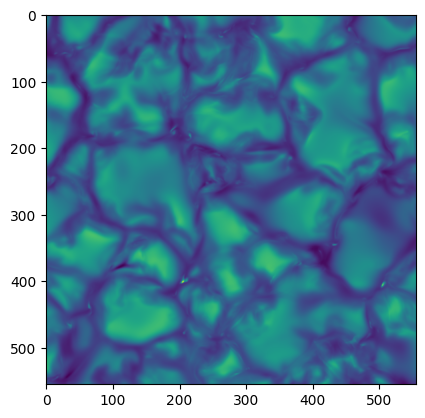

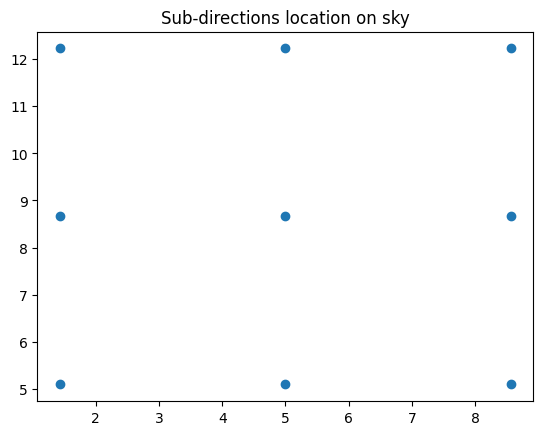

<Figure size 640x480 with 0 Axes>

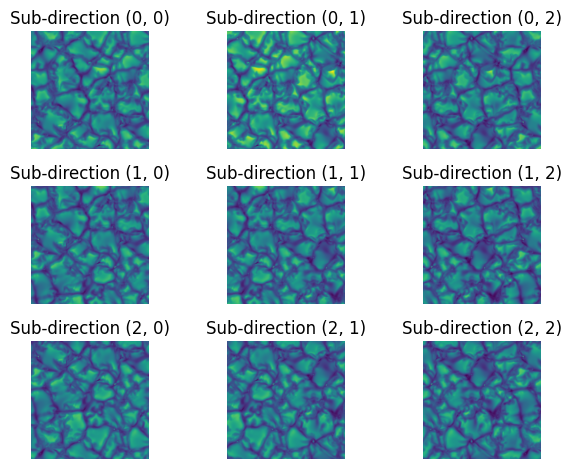

In [5]:
from SAOS.ExtendedSource import ExtendedSource

sun = ExtendedSource(optBand='R',
                     coordinates=[10, 60],
                     nSubDirs=3,
                     fov=9.269,
                     subDir_margin=4.0,
                     patch_padding=5.0,
                     logger=example_logger.logger)

example_logger.logger.info(f'Number of photons: {sun.nPhoton}, Coordinates [arcsec, degree]: {sun.coordinates}, Wavelength [m]: {sun.wavelength}')

plt.imshow(sun.sun_nopad)

x_subdirs = sun.subDirs_coordinates[0].flatten() * np.cos(sun.subDirs_coordinates[1].flatten() * (np.pi/180))
y_subdirs = sun.subDirs_coordinates[0].flatten() * np.sin(sun.subDirs_coordinates[1].flatten() * (np.pi/180))
plt.figure()
plt.title('Sub-directions location on sky')
plt.scatter(x_subdirs, y_subdirs)
plt.show()

plt.figure()
_, axs = plt.subplots(3,3)

for i in range(sun.nSubDirs**2):
    dirX = i // sun.nSubDirs
    dirY = i % sun.nSubDirs
    axs[dirX, dirY].imshow(sun.subDirs_sun[:, :, dirX, dirY])
    axs[dirX, dirY].axis('off')
    axs[dirX, dirY].set_title(f'Sub-direction ({dirX}, {dirY})')

plt.tight_layout()
plt.show()



## Atmosphere
The `Atmosphere` class models a multi-layer turbulent atmosphere using Von Kármán statistics.

It is defined by several parameters per layer, provided as lists:
- `r0`: Fried parameter at 500 nm [m].
- `L0`: Outer scale of turbulence [m].
- `windSpeed`, `windDirection`, `altitude`, `fractionalR0`: Lists defining the properties of each atmospheric layer.
- `telescope`: The telescope object is linked to ensure the phase screens match the telescope's resolution and diameter.

Once the object is created, we must call `initializeAtmosphere()` to generate the phase screens. We can then obtain the Optical Path Difference (OPD) for any given source using `getOPD(source)`.

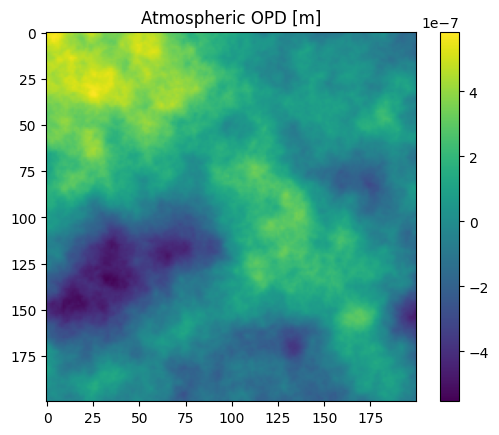

In [6]:
from SAOS.Atmosphere import Atmosphere

atm = Atmosphere(r0=0.15,
                 L0=30,
                 windSpeed=[10.0, 5.0],
                 fractionalR0=[0.7, 0.3],
                 windDirection=[0.0, 90.0],
                 altitude=[0.0, 5000.0],
                 telescope=tel,
                 logger=example_logger.logger)

atm.initializeAtmosphere()

opd = atm.getOPD(ngs)
plt.figure()
plt.title('Atmospheric OPD [m]')
plt.imshow(opd)
plt.colorbar()
plt.show()



## Shack-Hartmann Wavefront Sensor
The `ShackHartmann` class models a Shack-Hartmann Wavefront Sensor (SH-WFS). It simulates the lenslet array, the detector, and the centroiding algorithm.

Key parameters include:
- `nSubap`: Number of subapertures across the pupil diameter.
- `plate_scale`: Plate scale of the WFS in [arcsec/px].
- `fieldOfView`: Field of view of each subaperture in [arcsec].
- `guardPx`: Number of pixels between subapertures.
- `lightRatio`: Efficiency threshold.

To measure the slopes, we use the `wfs_measure(phase, source)` method, which takes the incoming phase in radians and the source object, and returns the 1D slopes, 2D slopes, and the resulting camera frame.

2026-05-16 18:39:27,829 - INFO - ShackHartmann::__init__ - Selecting valid subapertures based on flux considerations..
2026-05-16 18:39:27,833 - INFO - ShackHartmann::initialize_wfs - Acquiring reference slopes..
2026-05-16 18:39:27,878 - INFO - ShackHartmann::initialize_wfs - Setting slopes units..
2026-05-16 18:39:27,879 - INFO - ShackHartmann::initialize_wfs - Done!
2026-05-16 18:39:27,879 - INFO - %%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SHACK HARTMANN WFS %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
2026-05-16 18:39:27,879 - INFO -     Subapertures            10        
2026-05-16 18:39:27,879 - INFO -   Subaperture Size         0.15              [m]        
2026-05-16 18:39:27,879 - INFO -    Subapertue FoV          5.0             [arcsec]     
2026-05-16 18:39:27,879 - INFO -  Valid Subaperture          32        


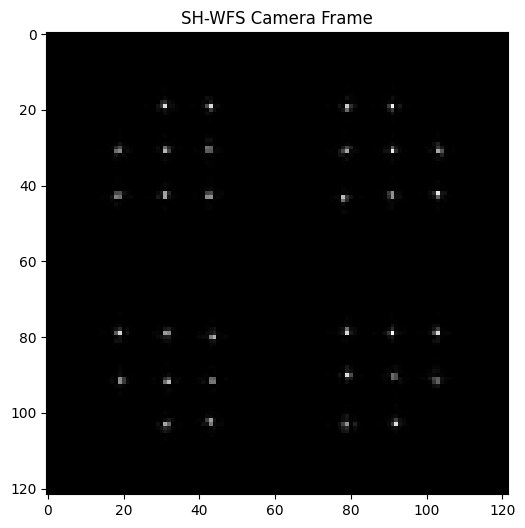

In [7]:
from SAOS.ShackHartmann import ShackHartmann

wfs = ShackHartmann(device='cpu', nSubap=10,
                    telescope=tel,
                    src=ngs,
                    lightRatio=1.0,
                    plate_scale=0.5,
                    fieldOfView=5.0,
                    guardPx=2,
                    logger=example_logger.logger)

# The phase must be passed in radians. We convert the OPD [m] to phase [rad]
phase = opd * (2 * np.pi / ngs.wavelength)

signal, signal_2D, camera_frame = wfs.wfs_measure(phase, ngs)

plt.figure(figsize=(6,6))
plt.title('SH-WFS Camera Frame')
plt.imshow(camera_frame, cmap='gray')
plt.show()



## Correlating Shack-Hartmann Wavefront Sensor
For extended sources like the Sun, standard centroiding algorithms fail because the subapertures image a complex, extended field rather than a point source. The `CorrelatingShackHartmann` class solves this by performing cross-correlation between the subaperture images and a reference image to determine the local wavefront slopes.

It shares the same parameter structure as the standard `ShackHartmann`, but requires an `ExtendedSource` (like our `sun` object) as its input source.

2026-05-16 18:39:28,195 - INFO - CorrelatingShackHartmann::__init__ - Selecting valid subapertures based on flux considerations..


Number of valid subapertures: 32


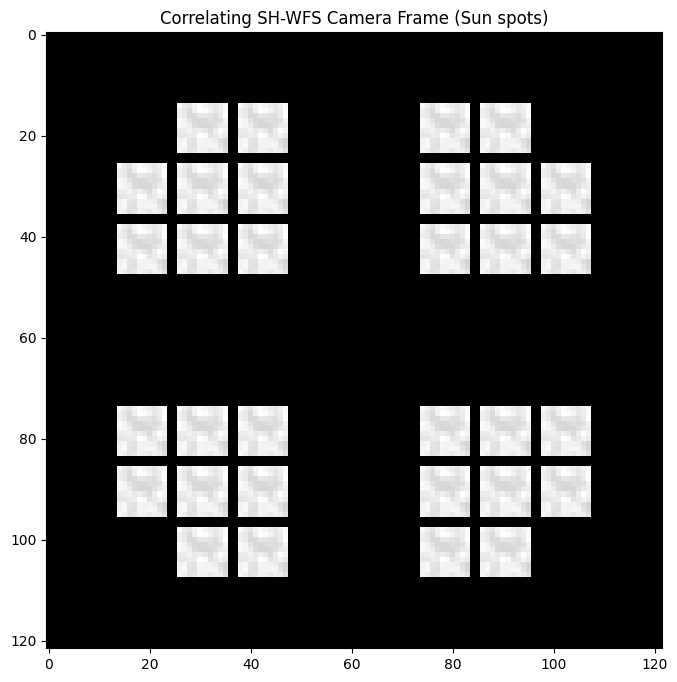

In [8]:
from SAOS.CorrelatingShackHartmann import CorrelatingShackHartmann

cwfs = CorrelatingShackHartmann(device='cpu', nSubap=10,
                                telescope=tel,
                                src=sun,
                                lightRatio=1.0,
                                plate_scale=0.5,
                                fieldOfView=5.0,
                                guardPx=2,
                                logger=example_logger.logger)

print(f'Number of valid subapertures: {cwfs.nValidSubaperture}')



# For the correlating WFS, the phase input requires one phase screen per sub-direction of the extended source.
phase_cwfs = np.zeros((sun.nSubDirs**2, tel.resolution, tel.resolution))
signal_c, signal_2D_c, camera_frame_c, pseudoref = cwfs.wfs_measure(phase_cwfs, sun)

plt.figure(figsize=(8,8))
plt.title('Correlating SH-WFS Camera Frame (Sun spots)')
plt.imshow(camera_frame_c, cmap='gray')
plt.show()



## Deformable Mirror (DM)
The `DeformableMirror` class models the adaptive optics corrector. SAOS supports multiple geometries via the `typeDM` parameter:
- `'cartesian'`: Standard square grid of actuators.
- `'radial'`: Circular/polar grid of actuators.
- `'custom'`: User-defined coordinates and modal basis.

### Valid Actuators & Threshold (`validActThreshpercentage`)
The simulation automatically determines which actuators are valid by checking their location against the telescope pupil. The `validActThreshpercentage` parameter allows you to control the strictness of this selection: it defines the maximum distance (as a percentage of the actuator pitch) an actuator can be outside the pupil boundary and still be considered 'valid'.

### State-Space Dynamics
You can optionally simulate the temporal dynamics of the DM by passing the path to an HDF5 file via `dynamicModel`. This `.h5` file must contain the state-space matrices `A`, `B`, `C`, and `D`. The sampling frequency of the model must exactly match the simulation's `samplingTime`.

In [9]:
from SAOS.DeformableMirror import DeformableMirror
import torch

# Cartesian DM example
dm_cart = DeformableMirror(device='cpu', telescope=tel,
                           nActs=11,
                           mechCoupling=0.60,
                           typeDM='cartesian',
                           validActThreshpercentage=0.5, # 50% pitch tolerance
                           logger=example_logger.logger)

# Radial DM example
dm_radial = DeformableMirror(device='cpu', telescope=tel,
                             nActs=11,
                             mechCoupling=0.60,
                             typeDM='radial',
                             validActThreshpercentage=0.5,
                             logger=example_logger.logger)

print(f'Cartesian valid actuators: {dm_cart.nValidAct}')
print(f'Radial valid actuators: {dm_radial.nValidAct}')



Cartesian valid actuators: 97
Radial valid actuators: 109


### Actuator Geometry Visualization
We can visualize the valid and invalid actuators for both geometries using a scatter plot of their coordinates.

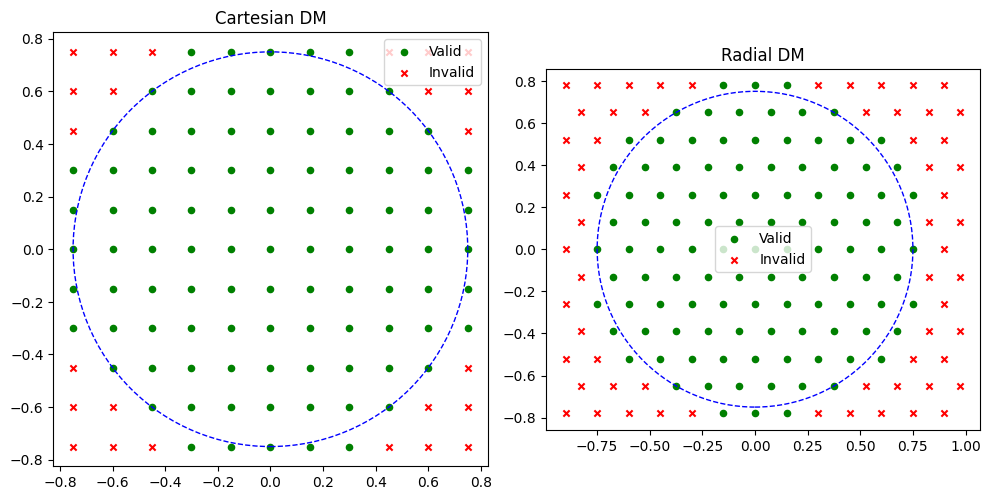

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for ax, dm, title in zip(axs, [dm_cart, dm_radial], ['Cartesian DM', 'Radial DM']):
    coords = dm.coordinates
    valid = dm.validAct
    
    # Plot valid actuators
    ax.scatter(coords[valid, 0], coords[valid, 1], c='green', label='Valid', s=20)
    # Plot invalid actuators
    ax.scatter(coords[~valid, 0], coords[~valid, 1], c='red', marker='x', label='Invalid', s=20)
    
    # Draw the telescope pupil boundary for reference
    pupil_radius = tel.D / 2
    circle = plt.Circle((0, 0), pupil_radius, color='blue', fill=False, linestyle='--')
    ax.add_patch(circle)
    
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.show()



### Influence Functions
We can visualize the influence function of a single actuator by pushing a command of `1.0` to it and displaying the resulting Optical Path Difference (OPD) of the mirror surface.

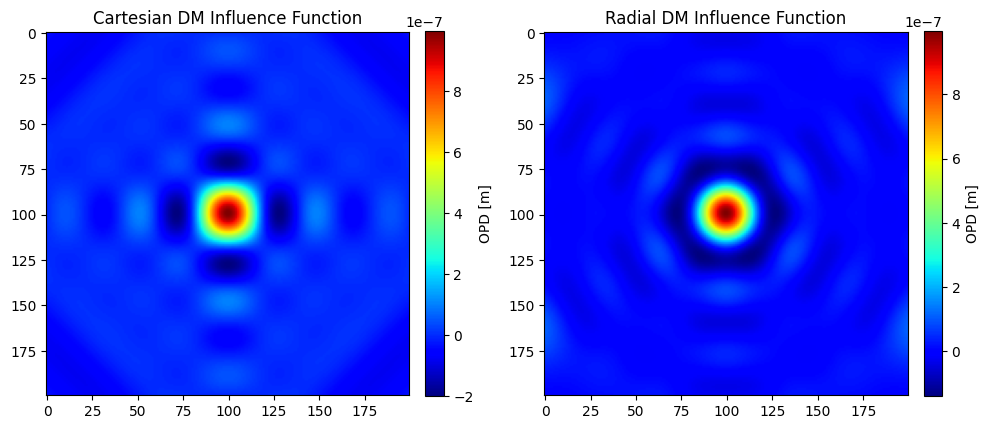

In [11]:
# Set a feasible stroke (e.g., 1 micron) to avoid saturating the DM (default max stroke is 100 microns)
stroke = 1e-6

# Create commands for both DMs
cmd_cart = torch.zeros(dm_cart.nValidAct, device=dm_cart.device, dtype=torch.float64)
cmd_radial = torch.zeros(dm_radial.nValidAct, device=dm_radial.device, dtype=torch.float64)

# Poke the central actuator
cmd_cart[dm_cart.nValidAct // 2] = stroke
cmd_radial[dm_radial.nValidAct // 2] = stroke

# Update shapes
dm_cart.updateDMShape(cmd_cart)
dm_radial.updateDMShape(cmd_radial)

# Visualize both side-by-side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

im1 = axs[0].imshow(dm_cart.dm_layer.OPD, cmap='jet')
axs[0].set_title('Cartesian DM Influence Function')
fig.colorbar(im1, ax=axs[0], label='OPD [m]', fraction=0.046, pad=0.04)

im2 = axs[1].imshow(dm_radial.dm_layer.OPD, cmap='jet')
axs[1].set_title('Radial DM Influence Function')
fig.colorbar(im2, ax=axs[1], label='OPD [m]', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



## Science Camera (`ScienceCam`)
The `ScienceCam` class simulates the science detector. It evaluates the final Optical Path Difference (OPD) to generate the Point Spread Function (PSF) or the convolved extended image.

Key parameters include the `fieldOfView`, the `plate_scale`, and the `integrationTime` (which can span multiple simulation steps). It also supports detector noise simulation if `noiseFlag` is enabled.

In [12]:
from SAOS.ScienceCam import ScienceCam

sci_cam = ScienceCam(device='cpu', fieldOfView=2.0,
                     plate_scale=0.0128,
                     samplingTime=tel.samplingTime,
                     telescope=tel,
                     integrationTime=1.0, # 1 second exposure
                     noiseFlag=True,
                     logger=example_logger.logger)

print(f'Science Camera initialized with a {sci_cam.nPix}x{sci_cam.nPix} pixel array.')



Science Camera initialized with a 156x156 pixel array.


## Optical Path (`LightPath`)
In SAOS, you don't need to manually pass the OPD from the atmosphere to the DM and then to the WFS at each iteration. Instead, the `LightPath` class encapsulates the entire optical train for a specific line of sight.

You initialize it with `initialize_path(src, tel, atm, dm, wfs, sci, ...)`. Then, at each simulation step, you simply call `propagate(temporal_tick=True)`.

The `propagate` method automatically queries all active components and sums their Optical Path Differences (OPDs). It makes available several data buffers that you can read to analyze the state of the simulation:
- **OPD and Phase Buffers**: `wfs_opd`, `wfs_phase`, `sci_opd`, `sci_phase`.
- **WFS Measurements**: `slopes_1D`, `slopes_2D`, `wfs_frame`.
- **Science Images**: `sci_frame` (instantaneous short-exposure) and `long_exposure_frame` (accumulated over `integrationTime`).

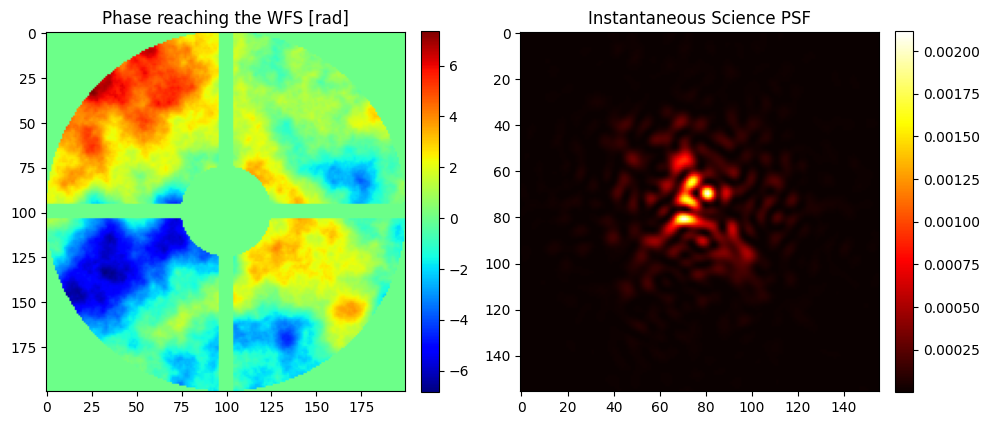

In [13]:
from SAOS.LightPath import LightPath

# Create a LightPath linking our previously created objects
ngs_path = LightPath(logger=example_logger.logger)

ngs_path.initialize_path(src=ngs,
                         tel=tel,
                         atm=atm,
                         dm=dm_cart,
                         wfs=wfs,
                         sci=sci_cam)

# Propagate light through all components for one simulation step
ngs_path.propagate(temporal_tick=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# We can access the buffers directly from the LightPath object
im1 = axs[0].imshow(ngs_path.wfs_phase, cmap='jet')
axs[0].set_title('Phase reaching the WFS [rad]')
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)

im2 = axs[1].imshow(ngs_path.sci_frame, cmap='hot')
axs[1].set_title('Instantaneous Science PSF')
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



### Solar LightPath
We can apply the exact same architecture to our solar simulation. We instantiate a second `LightPath`, but this time we link it with the `ExtendedSource` (`sun`) and the `CorrelatingShackHartmann` (`cwfs`).

2026-05-16 18:39:32,115 - INFO - CorrelatingShackHartmann::initialize_wfs - Acquiring reference slopes..
2026-05-16 18:39:32,248 - INFO - CorrelatingShackHartmann::initialize_wfs - Done!


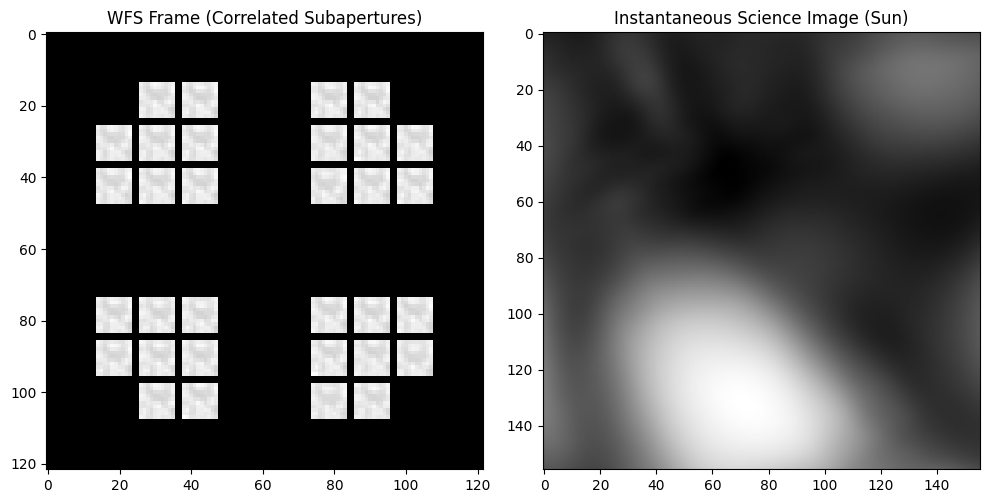

In [14]:
# Create a LightPath for the Sun
sun_path = LightPath(logger=example_logger.logger)

sun_path.initialize_path(src=sun,
                         tel=tel,
                         atm=atm,
                         dm=dm_cart,
                         wfs=cwfs,
                         sci=sci_cam)

# Propagate light through all components
sun_path.propagate(temporal_tick=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Visualize the WFS camera frame
axs[0].imshow(sun_path.wfs_frame, cmap='gray')
axs[0].set_title('WFS Frame (Correlated Subapertures)')

# Visualize the Science camera frame (convoluted solar patch)
axs[1].imshow(sun_path.sci_frame, cmap='gray')
axs[1].set_title('Instantaneous Science Image (Sun)')

plt.tight_layout()
plt.show()



## 6. Interaction Matrix & Modal Bases
The `InteractionMatrixHandler` class automates the measurement of the Interaction Matrix (IM). When you initialize it with your `LightPath` objects, it automatically detects which DMs affect which WFSs and creates an `im_boolean_matrix`.

Before measuring the IM, you can generate the **modal bases**. SAOS natively supports 5 bases: Zonal, Zernike, Karhunen-Loeve (KL), Hadamard, and Disk Harmonic (DH).
Let's generate them and visualize the first 10 modes of each basis for our Cartesian DM.

2026-05-16 18:43:48,749 - INFO - InteractionMatrixHandler::generate_modal_basis - Generating modal basis
2026-05-16 18:43:48,846 - INFO - InteractionMatrixHandler::generate_modal_basis - Modal basis generated, took 0.0969855785369873 [s]


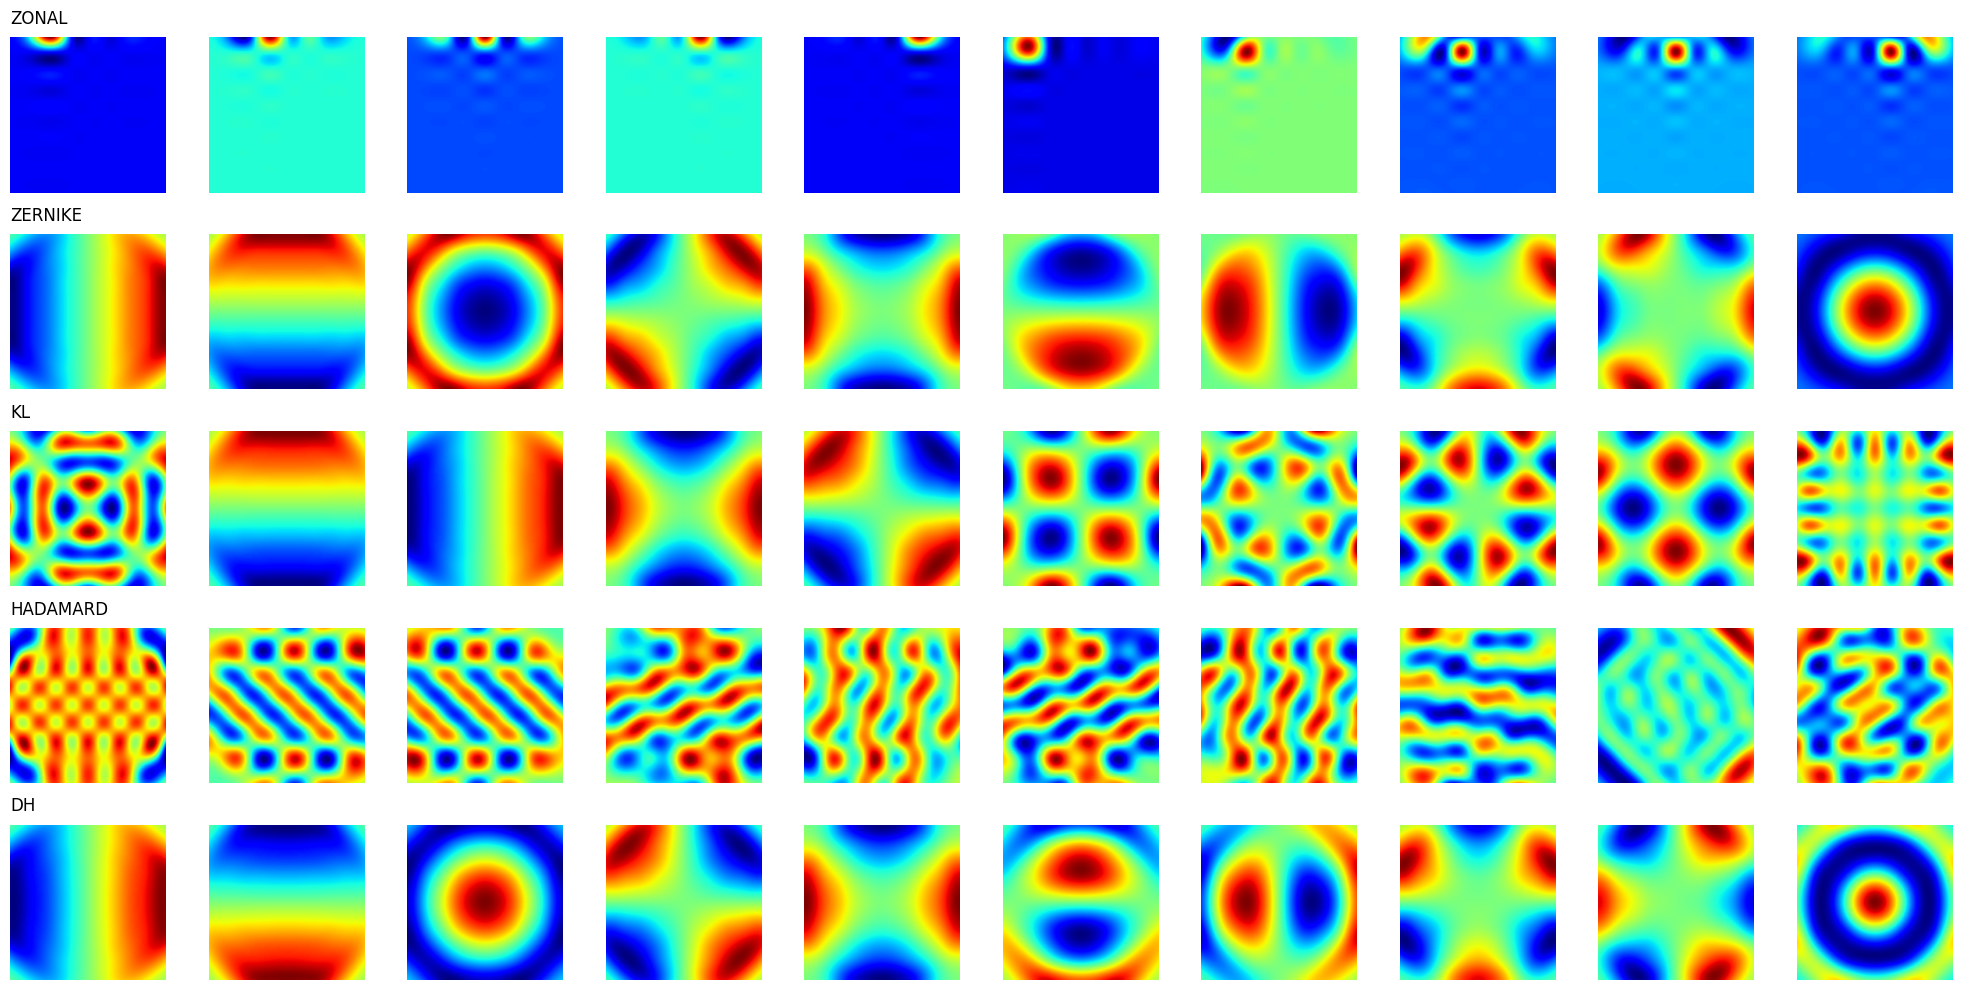

True

In [15]:
from SAOS.InteractionMatrixHandler import InteractionMatrixHandler
import torch

# Initialize the IM handler
im_handler = InteractionMatrixHandler(logger=example_logger.logger)

# Link it to our solar LightPath
im_handler.initialize_im_class(light_path_list=[sun_path])

# Generate all the modal bases
im_handler.generate_modal_basis()

# Visualize the first 10 modes of each basis
fig, axs = plt.subplots(len(im_handler.modal_list), 10, figsize=(20, 10))

for i, basis in enumerate(im_handler.modal_list):
    modes = im_handler.modal_basis[0][basis] # DM 0
    for j in range(10):
        cmd = modes[:, j] * 1e-6 # 1 micron stroke
        dm_cart.updateDMShape(torch.as_tensor(cmd, dtype=torch.float64, device=dm_cart.device).unsqueeze(1), dynamicResponse=False)
        
        axs[i, j].imshow(dm_cart.dm_layer.OPD, cmap='jet')
        axs[i, j].axis('off')
        if j == 0:
            axs[i, j].set_title(f"{basis.upper()}", fontsize=12, pad=10, loc='left')

plt.tight_layout()
plt.show()

# Flatten DM
dm_cart.updateDMShape(torch.zeros((dm_cart.nValidAct, 1), dtype=torch.float64, device=dm_cart.device), dynamicResponse=False)


## 7. Controller and Reconstructor
The `Controller` class manages the closed-loop dynamics. During initialization, it computes the **Reconstructor** matrix from the Interaction Matrix using either pseudo-inversion (`inversion`) or MMSE (`tikhonov`).

To support multi-conjugate systems (MCAO), you must provide a boolean `control_mask` matrix. This matrix defines the routing: its dimensions are `[nDMs, nLightPaths]`. If `control_mask[i, j] = True`, the slopes measured in `LightPath[j]` will be used to compute commands for `DM[i]`.

The dimensions and order of the DMs and LightPaths in the `control_mask` must perfectly match the order in which they were presented to the `InteractionMatrixHandler`.

## 8. Telemetry: Savepoint and Sharepoint
To record the simulation data or stream it live, SAOS provides two utility classes:

- **`Savepoint`**: Dumps telemetry into an HDF5 file. You instantiate it with decimation flags (e.g., `slopes=10` means save slopes every 10 iterations, `0` means do not save). Inside your simulation loop, you simply call `savepoint.save(light_paths, iteration)`.
- **`Sharepoint`**: Publishes telemetry via ZeroMQ to be consumed by external dashboards or controllers in real-time. It uses identical decimation flags and is called via `sharepoint.shareData(light_paths, iteration)`.

## 9. Closed loop operation

We provide several examples showing closed loop operation and the implementation of different AO schemes: SCAO, GLAO and MCAO, point and extended source alike. We invite you to continue the introduction to SAOS by running those scripts!